# Factor risk model, explained with a toy universe

This notebook walks through `trading_strategies.risk` piece by piece, using a
small **synthetic** universe with correlations we choose ourselves. Because we
know the ground truth (the generating correlation matrix, the vol regimes, a
planted trend), we can check the model actually recovers what it should — and
you can retune the knobs in the second cell and rerun everything below.

Order:

1. Build a toy universe with known correlations (Cholesky from a target
   correlation matrix).
2. `EwmCovariance` — the one streaming estimator everything else is built
   from. Check it recovers the known vols/correlations.
3. Macro factors: `factor_weight_matrix` + `residualize` — see what
   hierarchical residualization actually does to a factor's ETF weights.
4. `FactorRiskModel` end to end: stream bars in, inspect `B`, `F`, `D`, and
   check `Σ = B F Bᵀ + D` against the known truth.
5. Momentum: plant a trend on one asset, watch `momentum_exposures` find it.
6. Playground — knobs collected in one place to try your own scenarios.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from trading_strategies.utils.streaming import EwmCovariance
from trading_strategies.risk.factors import FactorDefinition, factor_weight_matrix, residualize
from trading_strategies.risk.style_factors import MomentumSignal, momentum_exposures
from trading_strategies.risk.model import FactorRiskModel, IDIOSYNCRATIC, MOMENTUM
from trading_strategies.risk.config import FactorModelConfig, MomentumConfig

pd.set_option("display.precision", 3)
rng = np.random.default_rng(7)

## 1. A toy universe with known correlations

Six tickers in two "macro" clusters plus one independent name:

- `EQ_US`, `EQ_INTL` — highly correlated with each other (same equity factor).
- `RATE_A`, `RATE_B` — a second cluster (a rates factor), weakly correlated
  with equities.
- `CREDIT` — correlated with **both** clusters (so residualization has
  something to do).
- `NOISE` — independent of everything.

We pick a target correlation matrix, set target annualized vols, and draw
correlated daily log returns from it with `numpy`'s Cholesky decomposition.
Because we generated the data, we know exactly what the model *should*
recover.

In [2]:
TICKERS = ["EQ_US", "EQ_INTL", "RATE_A", "RATE_B", "CREDIT", "NOISE"]

TARGET_CORR = pd.DataFrame(
    [
        [1.00, 0.85, 0.10, 0.05, 0.55, 0.00],
        [0.85, 1.00, 0.05, 0.05, 0.50, 0.00],
        [0.10, 0.05, 1.00, 0.75, 0.35, 0.00],
        [0.05, 0.05, 0.75, 1.00, 0.30, 0.00],
        [0.55, 0.50, 0.35, 0.30, 1.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00, 1.00],
    ],
    index=TICKERS,
    columns=TICKERS,
)

TARGET_ANNUAL_VOL = pd.Series(
    {"EQ_US": 0.16, "EQ_INTL": 0.18, "RATE_A": 0.06, "RATE_B": 0.07, "CREDIT": 0.10, "NOISE": 0.12}
)
TRADING_DAYS = 252
target_daily_vol = TARGET_ANNUAL_VOL / np.sqrt(TRADING_DAYS)
target_cov = (
    TARGET_CORR.to_numpy() * np.outer(target_daily_vol.to_numpy(), target_daily_vol.to_numpy())
)

chol = np.linalg.cholesky(target_cov)


def draw_returns(n_days: int, seed: int = 0) -> pd.DataFrame:
    generator = np.random.default_rng(seed)
    z = generator.standard_normal((n_days, len(TICKERS)))
    daily_returns = z @ chol.T
    dates = pd.bdate_range("2020-01-02", periods=n_days)
    return pd.DataFrame(daily_returns, index=dates, columns=TICKERS)


returns = draw_returns(n_days=1500, seed=1)
closes = 100.0 * np.exp(returns.cumsum())
closes.head()

,EQ_US,EQ_INTL,RATE_A,RATE_B,CREDIT,NOISE
2020-01-02,100.349,100.827,100.116,99.745,100.601,100.338
2020-01-03,99.807,100.656,100.219,99.942,100.533,100.754
2020-01-06,99.069,99.846,100.014,99.939,100.224,100.531
2020-01-07,98.292,98.945,99.994,99.843,100.564,101.299
2020-01-08,95.642,95.311,99.873,99.592,99.604,101.466


## 2. `EwmCovariance`: does it recover the known truth?

The model is built entirely from `EwmCovariance` (`covariance.py`): a
pairwise-complete, bias-corrected EWM covariance, matching
`DataFrame.ewm(span=..., adjust=True).cov()`. We feed it the same synthetic
returns bar by bar and compare the converged correlation matrix to
`TARGET_CORR`, and the converged vols to `TARGET_ANNUAL_VOL`.

In [3]:
corr_estimator = EwmCovariance(TICKERS, span=250, min_periods=250)
for _, row in returns.iterrows():
    corr_estimator.update(row.to_dict())

cov_hat = corr_estimator.covariance()
vol_hat = np.sqrt(np.diag(cov_hat))
corr_hat = cov_hat / np.outer(vol_hat, vol_hat)

recovered_annual_vol = pd.Series(vol_hat * np.sqrt(TRADING_DAYS), index=TICKERS)
print("Recovered annualized vol vs target:")
display(pd.DataFrame({"recovered": recovered_annual_vol, "target": TARGET_ANNUAL_VOL}))

Recovered annualized vol vs target:


,recovered,target
EQ_US,0.168,0.16
EQ_INTL,0.186,0.18
RATE_A,0.056,0.06
RATE_B,0.066,0.07
CREDIT,0.109,0.10
NOISE,0.131,0.12


Text(0.5, 0.98, 'Correlation: target vs. what EwmCovariance recovers after 1500 bars')

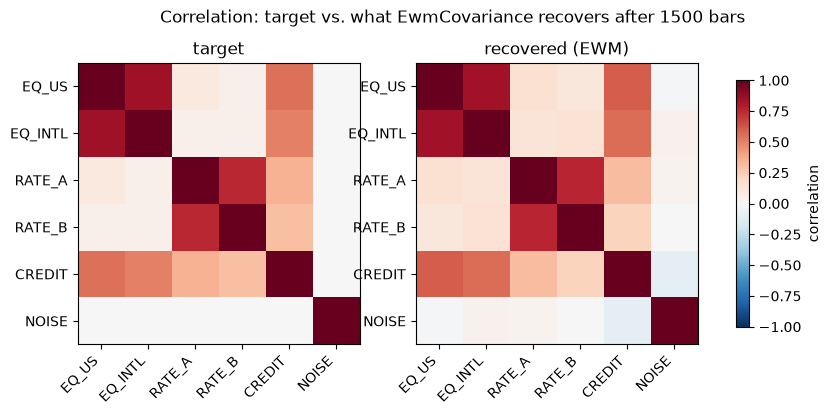

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in zip(axes, [TARGET_CORR.to_numpy(), corr_hat], ["target", "recovered (EWM)"]):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(TICKERS)), TICKERS, rotation=45, ha="right")
    ax.set_yticks(range(len(TICKERS)), TICKERS)
    ax.set_title(title)
fig.colorbar(im, ax=axes, shrink=0.8, label="correlation")
fig.suptitle("Correlation: target vs. what EwmCovariance recovers after 1500 bars")

## 3. Macro factors: weights, and what residualization does

A factor is just a fixed portfolio of tickers (`FactorDefinition.weights`).
We define two toy macro factors on our universe:

- **Equity** (level 1): `EQ_US - EQ_INTL` is *not* what we want — instead use
  a simple long-only spread `0.5 EQ_US + 0.5 EQ_INTL`.
- **Rates** (level 1): `0.5 RATE_A + 0.5 RATE_B`.
- **Credit** (level 2): `CREDIT` alone — but `CREDIT` is correlated with
  *both* Equity and Rates (correlation 0.55 / 0.35 above), so once it's
  residualized against the level-1 factors, its weights should pick up small
  offsetting positions in the equity/rates names.

`factor_weight_matrix` builds the raw (pre-residualization) N x K weight
matrix; `residualize` does the GLS projection level by level.

In [5]:
toy_factors = [
    FactorDefinition("Equity", level=1, granular=False, weights={"EQ_US": 0.5, "EQ_INTL": 0.5}),
    FactorDefinition("Rates", level=1, granular=False, weights={"RATE_A": 0.5, "RATE_B": 0.5}),
    FactorDefinition("Credit", level=2, granular=False, weights={"CREDIT": 1.0}),
]

raw_weights = factor_weight_matrix(toy_factors, TICKERS, available=set(TICKERS))
raw_df = pd.DataFrame(raw_weights, index=TICKERS, columns=[f.name for f in toy_factors])
print("Raw factor weights (before residualization):")
display(raw_df)

levels = [f.level for f in toy_factors]
residualized = residualize(raw_weights, levels, cov_hat)
resid_df = pd.DataFrame(residualized, index=TICKERS, columns=[f.name for f in toy_factors])
print("Residualized factor weights — Credit now has small offsetting weights")
print("in the equity/rates names, since that's the part of Credit those factors already explain:")
display(resid_df)

Raw factor weights (before residualization):


,Equity,Rates,Credit
EQ_US,0.5,0.0,0.0
EQ_INTL,0.5,0.0,0.0
RATE_A,0.0,0.5,0.0
RATE_B,0.0,0.5,0.0
CREDIT,0.0,0.0,1.0
NOISE,0.0,0.0,0.0


Residualized factor weights — Credit now has small offsetting weights
in the equity/rates names, since that's the part of Credit those factors already explain:


,Equity,Rates,Credit
EQ_US,0.5,0.0,-0.185
EQ_INTL,0.5,0.0,-0.185
RATE_A,0.0,0.5,-0.184
RATE_B,0.0,0.5,-0.184
CREDIT,0.0,0.0,1.000
NOISE,0.0,0.0,0.000


In [6]:
raw_factor_returns = returns.to_numpy() @ raw_weights
resid_factor_returns = returns.to_numpy() @ residualized
raw_factor_corr = pd.DataFrame(raw_factor_returns, columns=raw_df.columns).corr()
resid_factor_corr = pd.DataFrame(resid_factor_returns, columns=raw_df.columns).corr()

print("Correlation between factor RETURNS, raw weights (Credit still correlated with Equity/Rates):")
display(raw_factor_corr)
print("Correlation between factor RETURNS, residualized weights (Credit now ~orthogonal to level-1):")
display(resid_factor_corr)

Correlation between factor RETURNS, raw weights (Credit still correlated with Equity/Rates):


,Equity,Rates,Credit
Equity,1.000,0.092,0.564
Rates,0.092,1.000,0.343
Credit,0.564,0.343,1.000


Correlation between factor RETURNS, residualized weights (Credit now ~orthogonal to level-1):


,Equity,Rates,Credit
Equity,1.000,0.092,-0.097
Rates,0.092,1.000,0.083
Credit,-0.097,0.083,1.000


## 4. `FactorRiskModel` end to end

Now the real thing: stream the same synthetic closes through
`FactorRiskModel.update()` bar by bar (exactly like the backtester would),
using our two-factor `configs/factors.json`-style file. After each bar we get
a causal `RiskModelSnapshot` with `B` (exposures), `F` (factor covariance),
`D` (specific variances), built from data up to and including that bar only.

We write the toy factor file next to this notebook, point a
`FactorModelConfig` at it, and check `Σ = B F Bᵀ + D` from the *last*
snapshot against the known target covariance.

In [7]:
import json

toy_factors_path = Path("toy_factors.json")
toy_factors_path.write_text(
    json.dumps(
        {
            "factors": [
                {"name": "Equity", "level": 1, "granular": False, "weights": {"EQ_US": 0.5, "EQ_INTL": 0.5}},
                {"name": "Rates", "level": 1, "granular": False, "weights": {"RATE_A": 0.5, "RATE_B": 0.5}},
                {"name": "Credit", "level": 2, "granular": False, "weights": {"CREDIT": 1.0}},
            ]
        }
    )
)

config = FactorModelConfig(
    factors_file=str(toy_factors_path),
    granular=False,
    vol_span=60,
    corr_span=250,
    corr_min_periods=250,
    residual_floor=0.10,
    momentum=MomentumConfig(lookback=252, skip=21),
)

model = FactorRiskModel(TICKERS, config)
snapshots = []
for date, row in closes.iterrows():
    model.update(row.to_dict())
    if model.snapshot.ready:
        snapshots.append((date, model.snapshot))

print(f"{len(snapshots)} ready snapshots out of {len(closes)} bars (warm-up needs {config.corr_min_periods}+ bars)")
last_date, last_snapshot = snapshots[-1]
print("Factors in the final snapshot:", last_snapshot.factors)

1250 ready snapshots out of 1500 bars (warm-up needs 250+ bars)
Factors in the final snapshot: ('Equity', 'Rates', 'Credit', 'Momentum')


Text(0.5, 0.98, 'Model-implied covariance recovers the generating covariance')

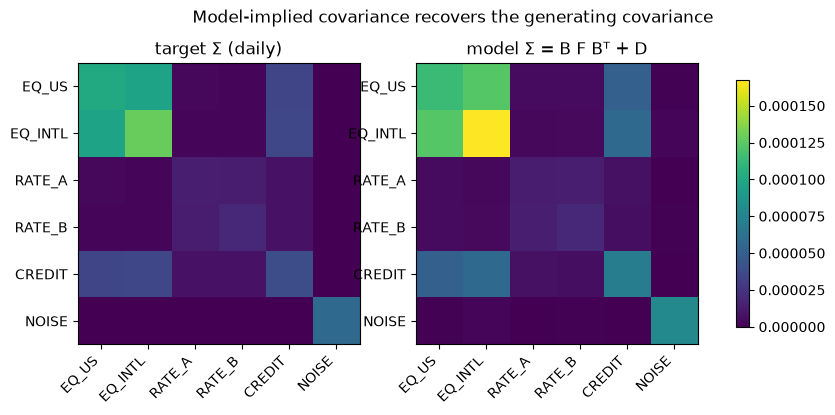

In [8]:
sigma_model = last_snapshot.covariance()
sigma_df = pd.DataFrame(sigma_model, index=last_snapshot.tickers, columns=last_snapshot.tickers)
target_df = pd.DataFrame(target_cov, index=TICKERS, columns=TICKERS)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = max(sigma_df.to_numpy().max(), target_df.to_numpy().max())
for ax, mat, title in zip(axes, [target_df, sigma_df], ["target Σ (daily)", "model Σ = B F Bᵀ + D"]):
    im = ax.imshow(mat, vmin=0, vmax=vmax, cmap="viridis")
    ax.set_xticks(range(len(TICKERS)), TICKERS, rotation=45, ha="right")
    ax.set_yticks(range(len(TICKERS)), TICKERS)
    ax.set_title(title)
fig.colorbar(im, ax=axes, shrink=0.8)
fig.suptitle("Model-implied covariance recovers the generating covariance")

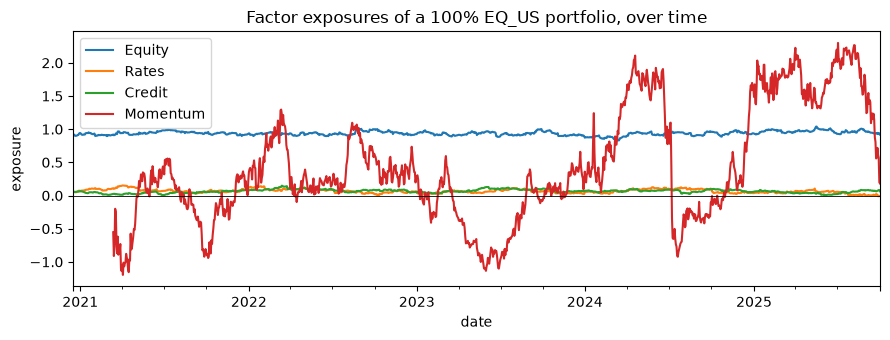

In [9]:
betas_over_time = pd.DataFrame(
    {date: dict(zip(snap.factors, snap.exposures(np.array([1.0 if t == "EQ_US" else 0.0 for t in snap.tickers]))))
     for date, snap in snapshots}
).T
betas_over_time.index.name = "date"

ax = betas_over_time.plot(figsize=(9, 3.5), title="Factor exposures of a 100% EQ_US portfolio, over time")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylabel("exposure")
plt.tight_layout()

A 100%-`EQ_US` portfolio should load almost entirely on **Equity** and
roughly zero on Rates/Credit once the model warms up — that's the sanity
check the plot above gives you directly.

### Risk decomposition of a mixed portfolio

Try a portfolio that's long the equity cluster and short a bit of rates —
`risk_decomposition` splits the variance into each factor's share plus
`IDIOSYNCRATIC` risk.

In [10]:
weights = {"EQ_US": 0.4, "EQ_INTL": 0.2, "RATE_A": -0.15, "RATE_B": -0.15, "CREDIT": 0.1, "NOISE": 0.1}
w = np.array([weights.get(t, 0.0) for t in last_snapshot.tickers])
shares = last_snapshot.risk_decomposition(w)
pd.Series(shares, name="share of variance").to_frame()

,share of variance
Equity,0.914
Rates,-0.003
Credit,0.006
Momentum,0.019
Idiosyncratic,0.064


## 5. Momentum: a planted trend

`MomentumSignal` tracks each ticker's 12-1 month return; `momentum_exposures`
winsorizes (median ± 3·1.4826·MAD) and z-scores it across the live universe.
We add a steady upward drift to `EQ_US` only, over and above its random walk,
and check that `EQ_US` gets the standout momentum z-score.

In [11]:
trend_returns = returns.copy()
DAILY_DRIFT = 0.0015  # ~38% annualized extra drift on EQ_US only
trend_returns["EQ_US"] = trend_returns["EQ_US"] + DAILY_DRIFT
trend_closes = 100.0 * np.exp(trend_returns.cumsum())

signal = MomentumSignal(TICKERS, lookback=252, skip=21)
last_sigma = None
for date, row in trend_closes.iterrows():
    signal.update(row.to_dict())

raw_mom = {t: value for t in TICKERS if (value := signal.raw_return(t)) is not None}
# reuse the model's recovered daily vols, scaled to annual, as sigma in momentum_exposures
sigma_for_momentum = {t: float(recovered_annual_vol[t]) for t in TICKERS}
exposures = momentum_exposures(raw_mom, sigma_for_momentum)
pd.Series(exposures, name="momentum z-score").sort_values(ascending=False).to_frame()

,momentum z-score
EQ_US,2.056
EQ_INTL,0.291
CREDIT,-0.214
NOISE,-0.426
RATE_A,-0.820
RATE_B,-0.888


`EQ_US` — the only ticker with a planted trend — should have the highest
(and likely only strongly positive) momentum z-score.

## 6. Playground

Everything above is driven by the knobs in the cell below. Change them and
re-run cells 2 onward (Kernel → Restart & Run All) to explore:

- `TARGET_CORR` / `TARGET_ANNUAL_VOL` in the setup cell — try decorrelating
  `CREDIT` from `Equity`/`Rates`, or making `NOISE` correlated after all.
- `DAILY_DRIFT` above — plant a trend on a different ticker, or reverse its
  sign, and see which name lights up in the momentum table.
- `config.residual_floor`, `config.vol_span`, `config.corr_span` — rebuild
  `FactorRiskModel` with different settings and compare `B`/`F`/`D`.
- Add a `NOISE`-only portfolio to the risk decomposition cell (section 4) —
  since `NOISE` is independent by construction, its variance should show up
  almost entirely as `IDIOSYNCRATIC`.

In [12]:
# Quick example: a pure-NOISE portfolio should be ~100% IDIOSYNCRATIC risk.
noise_only = np.array([1.0 if t == "NOISE" else 0.0 for t in last_snapshot.tickers])
pd.Series(last_snapshot.risk_decomposition(noise_only), name="share of variance").to_frame()

,share of variance
Equity,1.500e-04
Rates,1.877e-04
Credit,2.090e-02
Momentum,3.581e-05
Idiosyncratic,9.787e-01
